<html> <h1 style="font-style:bold; color:blue;"> Neural Computing and Deep Learning </h1> </html>

<html> <h1 style="font-style:italic; color:blue;"> Week-10 </h1> </html>

<html> <h2 style="font-style:italic; color:blue;"> Simple AutoEncoders with Image Data </h2> </html>

Here is a simple autoencoder with just the dense layers.


Load the data and import the libraries.

In [1]:
# Your code to import matplotlib, pandas and numpy libraries

#
#
#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import *
import seaborn as sns
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print(tf.__version__)
np.random.seed(19)



2.19.0


In [2]:
from keras.layers import Input, Dense
from keras.models import Model

from keras.datasets import mnist

In [3]:
# Your code to load MNIST data and store it in variables x_train, x_test. 
# Note -  we do not need labels as it's autoencoder.

#

(X_train, y_train), (X_test, y_test) = mnist.load_data()
print((X_train.shape, y_train.shape), (X_test.shape, y_test.shape))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
((60000, 28, 28), (60000,)) ((10000, 28, 28), (10000,))


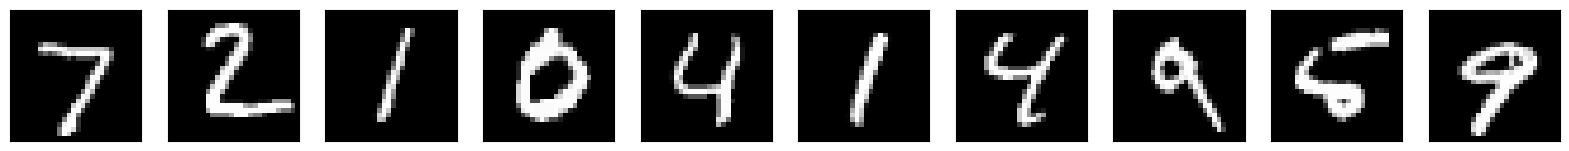

In [4]:
n = 10
plt.figure(figsize=(20,4))
for i in range(n):
    
    ax = plt.subplot(2, n, i+1)
    plt.imshow(X_test[i].reshape(28,28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    
plt.show()

In [5]:
# Your code to
# normalise train data - Divided by 255

#

# normalise test data - Divided by 255

#

X_train = X_train/255.
X_test = X_test/255.

<html> <h3 style="font-style:italic; color:blue;"> Basic AutoEncoder : </h3> </html>

Build a basic symmetric encoder-decoder network that recreates the image.  
This network could be used in dimensionaliry reduction or feature learning. 


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Reshape
from tensorflow.keras.optimizers import SGD

In [7]:
encoder = Sequential()
encoder.add(Flatten(input_shape=[28,28]))
encoder.add(Dense(1000, activation='relu'))
encoder.add(Dense(800, activation='relu'))
encoder.add(Dense(600, activation='relu'))
encoder.add(Dense(400, activation='relu'))
encoder.add(Dense(200, activation='relu'))
encoder.add(Dense(100, activation='relu'))
encoder.add(Dense(50, activation='relu'))
encoder.add(Dense(25, activation='relu'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
encoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1000)           │       785,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 800)            │       800,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 600)            │       480,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 400)            │       240,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 200)            │        80,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 25)             │         1,275 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,413,425 (9.21 MB)

 Trainable params: 2,413,425 (9.21 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
decoder = Sequential()
decoder.add(Dense(50,input_shape=[25],activation='relu'))

# Add as many layers in the Decoder as you want. 
# Reember - Encoder and Decoder must be symmetric.
decoder.add(Dense(25, activation='relu'))
decoder.add(Dense(50, activation='relu'))
decoder.add(Dense(100, activation='relu'))
decoder.add(Dense(200, activation='relu'))
decoder.add(Dense(400, activation='relu'))
decoder.add(Dense(600, activation='relu'))
decoder.add(Dense(800, activation='relu'))
decoder.add(Dense(1000, activation='relu'))
decoder.add(Dense(28 * 28, activation="sigmoid"))
decoder.add(Reshape([28, 28]))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
# Your code to print the Decoder model

#
decoder.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 50)             │         1,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 50)             │         1,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 100)            │         5,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 200)            │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 400)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 600)            │       240,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 800)            │       480,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1000)           │       801,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 784)            │       784,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,416,759 (9.22 MB)

 Trainable params: 2,416,759 (9.22 MB)

 Non-trainable params: 0 (0.00 B)

____________________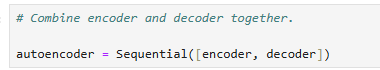

In [11]:
autoencoder = Sequential([encoder, decoder])

In [12]:
# Your code to print the Autoencoder model

autoencoder.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 25)             │     2,413,425 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 28, 28)         │     2,416,759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,830,184 (18.43 MB)

 Trainable params: 4,830,184 (18.43 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
#SGD?

In [14]:
# Your code to compile the Autoencoder. 
# Use binary_crossenropy as loss and metrics as accuracy.
sgd = tf.keras.optimizers.SGD(learning_rate=0.01)
#
autoencoder.compile(loss='binary_crossentropy', metrics=['accuracy'], optimizer='adam')

<html> <h3 style="font-style:italic; color:red;"> If you are using a personal laptop without a GPU, change the number of epochs to 10:  

epochs=10 </h3> </html> 

___________________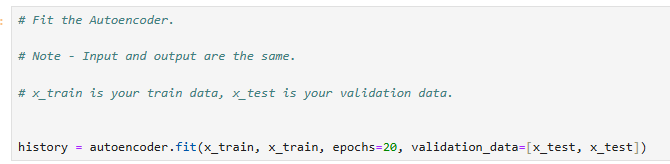

In [15]:
history = autoencoder.fit(X_train, X_train, epochs=20, validation_data=[X_test, X_test])

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.1335 - loss: 0.2091 - val_accuracy: 0.1738 - val_loss: 0.1743
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.1956 - loss: 0.1638 - val_accuracy: 0.2087 - val_loss: 0.1561
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.2120 - loss: 0.1529 - val_accuracy: 0.2076 - val_loss: 0.1532
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.2201 - loss: 0.1490 - val_accuracy: 0.2193 - val_loss: 0.1513
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.2234 - loss: 0.1466 - val_accuracy: 0.2207 - val_loss: 0.1445
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.2278 - loss: 0.1437 - val_accuracy: 0.2234 - val_loss: 0.1449
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.2328 - loss: 0.1405 - val_accuracy: 0.2293 - val_loss: 0.1398
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.2357 - loss: 0.1381 

____________________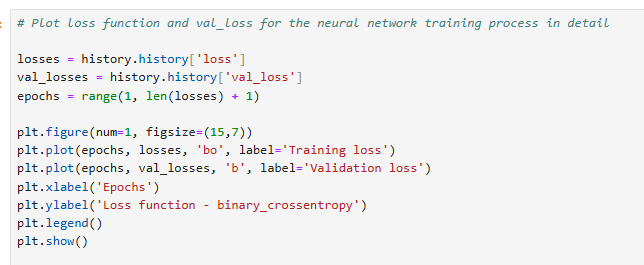

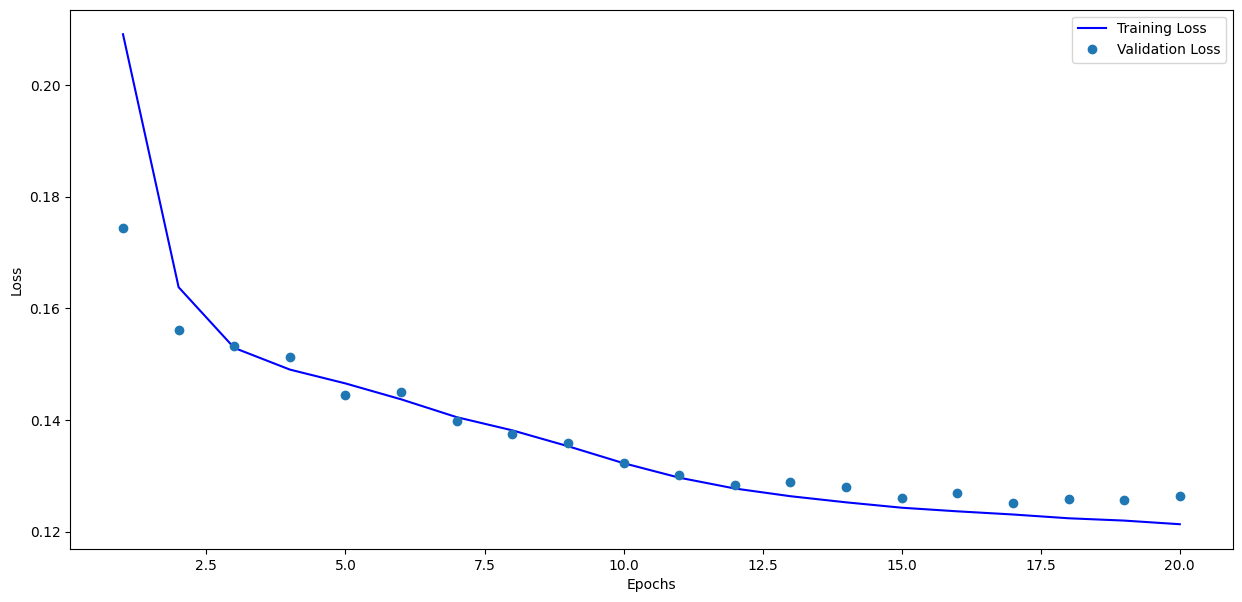

In [16]:
losses = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(losses) + 1)
plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, losses, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'o', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

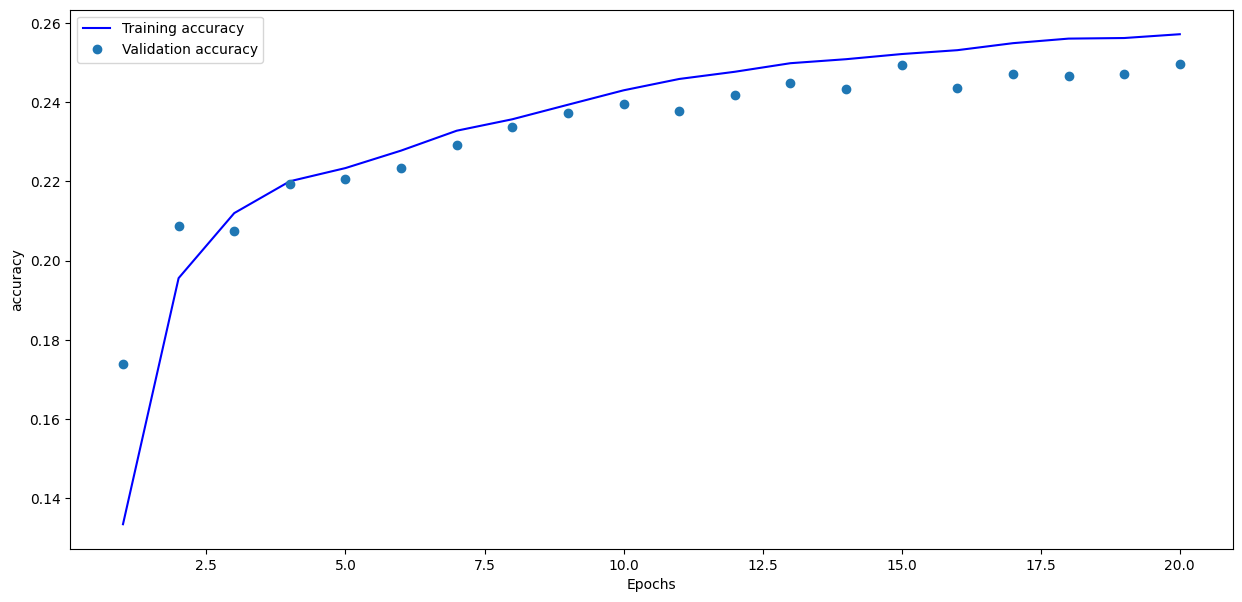

In [17]:
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, len(accuracy) + 1)
plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, accuracy, 'b', label='Training accuracy')
plt.plot(epochs, val_accuracy, 'o', label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

_______________________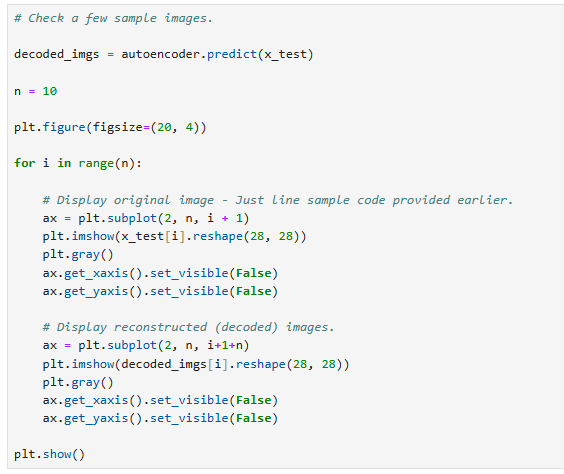

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


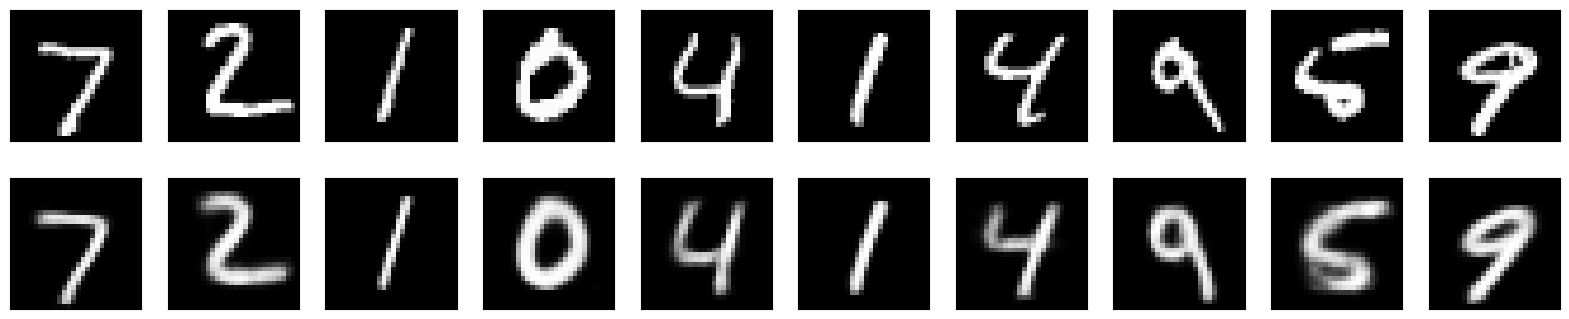

In [18]:
decoded_img = autoencoder.predict(X_test)

n = 10

plt.figure(figsize=(20,4))

for i in range(n):
    
    ax = plt.subplot(2, n, i+1)
    plt.imshow(X_test[i].reshape(28,28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    
    ax = plt.subplot(2, n, i+1+n)
    plt.imshow(decoded_img[i].reshape(28,28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    
plt.show()
    
    

<html> <h3 style="font-style:italic; color:blue;"> AutoEncoders for Denoising Images : </h3> </html>

Use the same digit data set. Add Gaussian noise to it to train an autoencoder that removes noise. Test the noisy samples. 


In [19]:
from tensorflow.keras.layers import GaussianNoise

___________________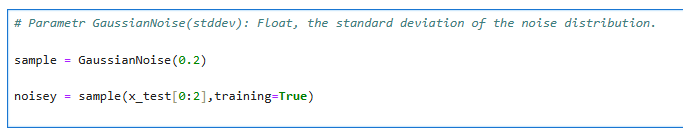

In [20]:
sample = GaussianNoise(0.2)
noisey = sample(X_test[0:2], training=True)

In [21]:
# Plot the original and noisy images

_______________________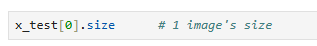

In [22]:
X_test[0].size

784

____________________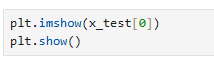

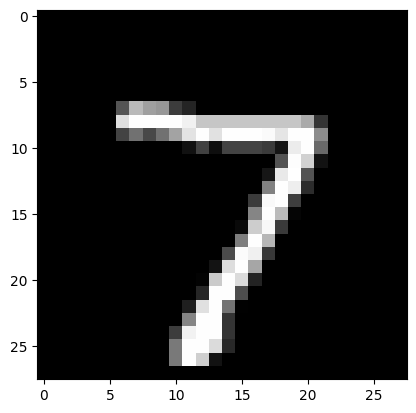

In [23]:
plt.imshow(X_test[0])
plt.show()

_____________________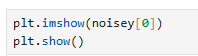

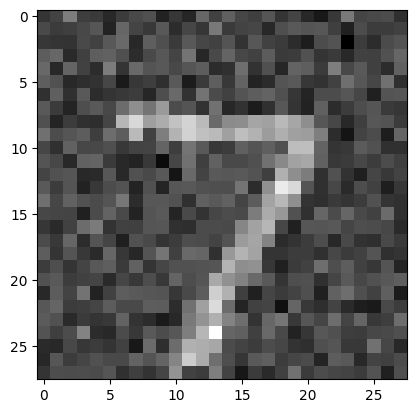

In [24]:
plt.imshow(noisey[0])
plt.show()

_________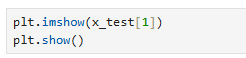

______________________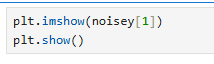

<html> <h4 style="font-style:italic; color:blue;"> Create a noise removal autoencoder and train it </h4> </html>

- Again similar to above it is a symmetric dense network. 
- Gaussian noise is added at the input so that the network sees noisy images and is able to map it to the clean outputs.


### Input - Images with noise
### Labels - Clean images.


In [25]:
# Encoder

encoder = Sequential()
encoder.add(Flatten(input_shape=[28,28]))
encoder.add(GaussianNoise(0.2)) # We are adding noise to make input as noisy images

encoder = Sequential()
encoder.add(Flatten(input_shape=[28,28]))
encoder.add(Dense(1000, activation='relu'))
encoder.add(Dense(800, activation='relu'))
encoder.add(Dense(600, activation='relu'))
encoder.add(Dense(400, activation='relu'))
encoder.add(Dense(200, activation='relu'))
encoder.add(Dense(100, activation='relu'))
encoder.add(Dense(50, activation='relu'))
encoder.add(Dense(25, activation='relu'))


print(encoder.summary())

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1000)           │       785,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 800)            │       800,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 600)            │       480,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 400)            │       240,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 200)            │        80,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 25)             │         1,275 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,413,425 (9.21 MB)

 Trainable params: 2,413,425 (9.21 MB)

 Non-trainable params: 0 (0.00 B)

None


In [26]:
# Your OWN Encoder model should be printed here 
# Please do not copy the model below

In [27]:
decoder = Sequential()
decoder.add(Dense(50,input_shape=[25],activation='relu'))

decoder.add(Dense(25, activation='relu'))
decoder.add(Dense(50, activation='relu'))
decoder.add(Dense(100, activation='relu'))
decoder.add(Dense(200, activation='relu'))
decoder.add(Dense(400, activation='relu'))
decoder.add(Dense(600, activation='relu'))
decoder.add(Dense(800, activation='relu'))
decoder.add(Dense(1000, activation='relu'))

decoder.add(Dense(28 * 28, activation="sigmoid"))
decoder.add(Reshape([28, 28]))

print(decoder.summary())

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                │ (None, 50)             │         1,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 50)             │         1,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 100)            │         5,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 200)            │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 400)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 600)            │       240,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 800)            │       480,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 1000)           │       801,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 784)            │       784,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 28, 28)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,416,759 (9.22 MB)

 Trainable params: 2,416,759 (9.22 MB)

 Non-trainable params: 0 (0.00 B)

None


_________________________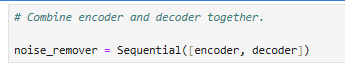

In [28]:
noise_remove = Sequential([encoder, decoder])

In [29]:
# Your code to print the Autoencoder model

#
noise_remove.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 25)             │     2,413,425 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 28, 28)         │     2,416,759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,830,184 (18.43 MB)

 Trainable params: 4,830,184 (18.43 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# Your code to compile the 'noise_remover' model with the same parameters as earlier

# noise_remover.compile( ................  )
noise_remove.compile(loss='binary_crossentropy', metrics=['accuracy'], optimizer='adam')

<html> <h3 style="font-style:italic; color:red;"> If you are using a personal laptop without a GPU, you should have epochs=10 </h3> </html> 

In [31]:
# Your code to fit 'noise_remover' model with the same parameters as earlier

# history_2 = ..........................
history2 = noise_remove.fit(X_train, X_train, epochs=20, validation_data=[X_test, X_test])

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.1269 - loss: 0.2139 - val_accuracy: 0.1644 - val_loss: 0.1870
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.1902 - loss: 0.1723 - val_accuracy: 0.1889 - val_loss: 0.1699
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.2020 - loss: 0.1658 - val_accuracy: 0.2012 - val_loss: 0.1619
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.2057 - loss: 0.1632 - val_accuracy: 0.2135 - val_loss: 0.1597
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.2101 - loss: 0.1593 - val_accuracy: 0.2108 - val_loss: 0.1563
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.2168 - loss: 0.1539 - val_accuracy: 0.2195 - val_loss: 0.1507
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.2209 - loss: 0.1508 - val_accuracy: 0.2160 - val_loss: 0.1508
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.2254 - loss: 0.147

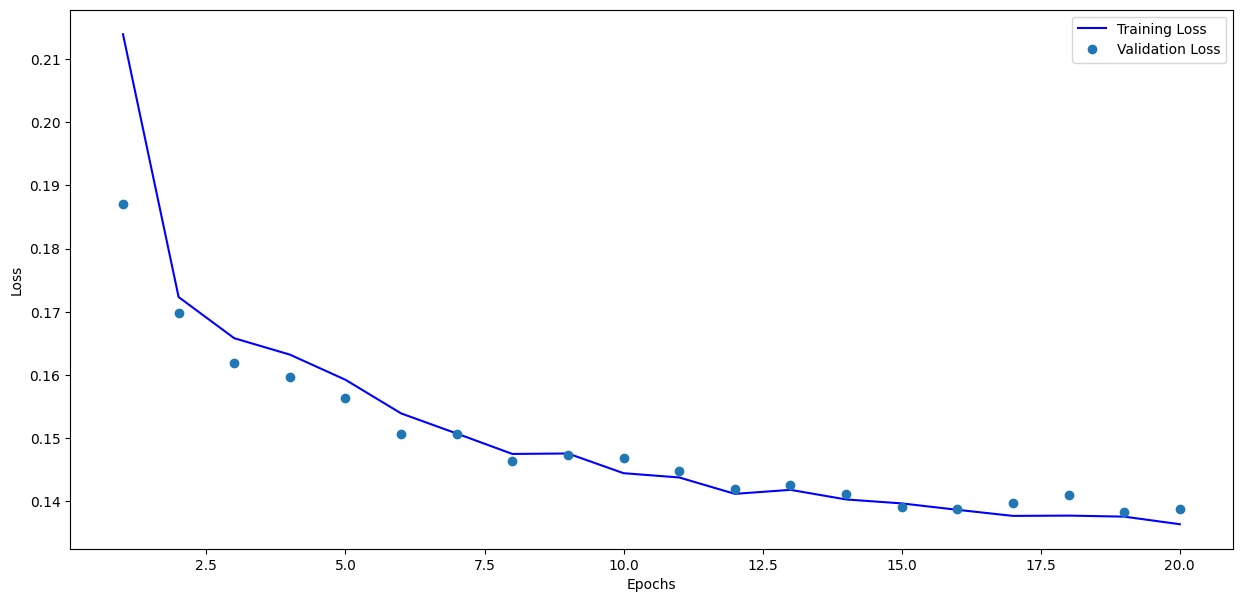

In [32]:
losses = history2.history['loss']
val_loss = history2.history['val_loss']
epochs = range(1, len(losses) + 1)
plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, losses, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'o', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

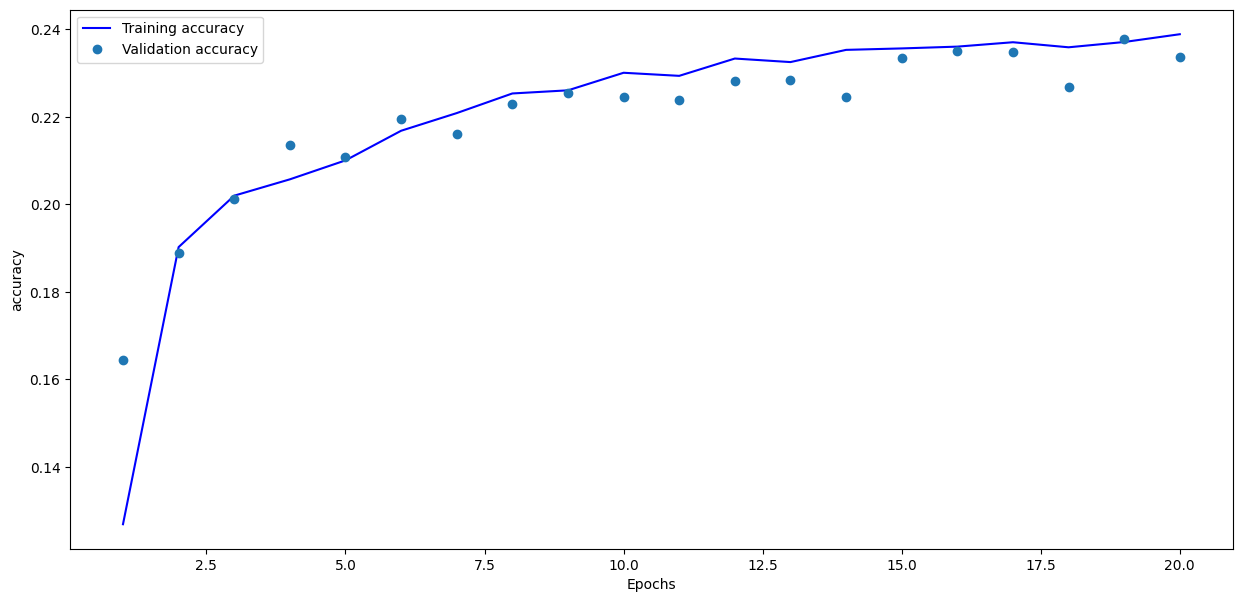

In [33]:
accuracy = history2.history['accuracy']
val_accuracy = history2.history['val_accuracy']
epochs = range(1, len(accuracy) + 1)
plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, accuracy, 'b', label='Training accuracy')
plt.plot(epochs, val_accuracy, 'o', label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

In [34]:
hundred_noisey_images = sample(X_test[0:100], training=True)
denoised = noise_remove(hundred_noisey_images[0:100])

In [35]:
import random

21
The Original


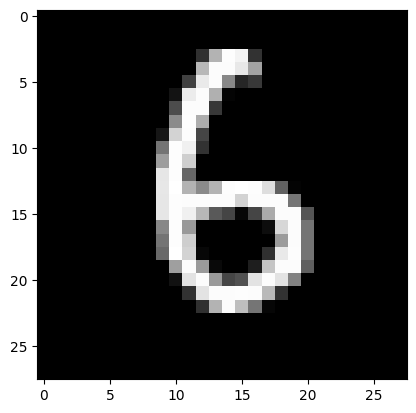

The Noisey Version


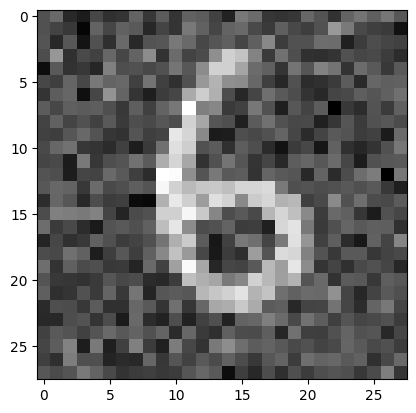

After going through denoiser


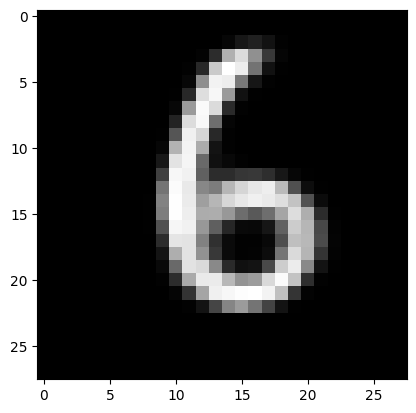

In [36]:
n = random.randint(0, 100)
print(n)

print('The Original')
plt.imshow(X_test[n])
plt.show()

print('The Noisey Version')
plt.imshow(hundred_noisey_images[n])
plt.show()

print('After going through denoiser')
plt.imshow(denoised[n])
plt.show()

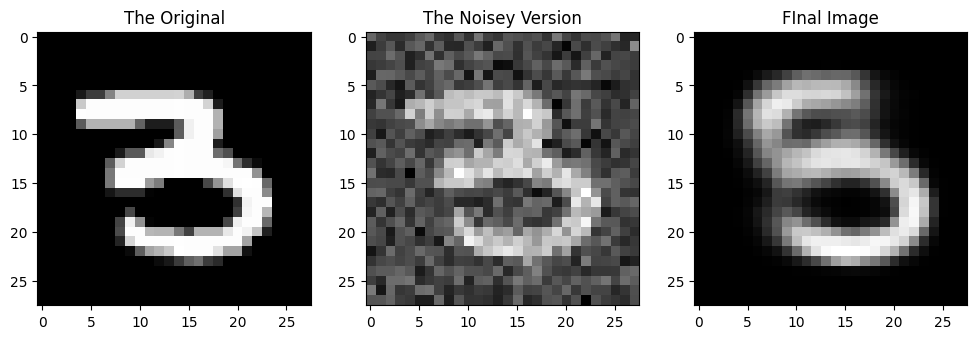

In [41]:
n = random.randint(0, 100)
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].imshow(X_test[n])
ax[0].set_title('The Original')

ax[1].imshow(hundred_noisey_images[n])
ax[1].set_title('The Noisey Version')

ax[2].imshow(denoised[n])
ax[2].set_title('FInal Image')
plt.show()

<html> <h3 style="font-style:italic; color:blue;"> You can run the previous cell multiple times </h3> </html>  

<html> <h2 style="font-style:bold; color:red;"> Lab Logbook requirements </h2> </html>

 - Put the Encoder, Decoder and Basic Autoencoder models using summary() in your lab logbook.

Ensure that no code or other information is added to the logbook and that only required information is present. Marks will not be awarded if anything else is found in the logbook or instructions are not clearly followed.

NOTE: DON'T FORGET TO SAVE AND BACK UP YOUR COMPLETED JUPYTER NOTEBOOK AND LAB LOGBOOK ON GITHUB.